In [53]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    PowerTransformer,
    StandardScaler
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import precision_score, recall_score


from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import shap


# problem scoping 

classifciation problem 

first do a baseline logistic regression model. 

If the model performs poorly or systematically misclassifies certain regions of feature space, that suggests non-linear decision boundaries, missing interactions or feature transformations are needed. 

After doing a baseline regression model if performance is insufficient, move onto ensemble models like XGBoost as they better capture nonlinear relationships. 

Use recall and precision to evaluate models as we dont want to miss churners.



# EDA

In [54]:
df = pd.read_csv('/Users/v/Documents/dataScienceProject/src/telco_churn.csv')

data integrity check

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

coerce total_charges to numeric

In [56]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [57]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.drop(columns=['customerID'])

In [58]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [59]:
df = df.dropna()

drop ID column

In [60]:
target = df['Churn']

In [61]:
target.describe()
#print((5174/7043)*100)

count     7032
unique       2
top         No
freq      5163
Name: Churn, dtype: object

heaavy class imbalance, stratification needed.

normal cardinality

# Univariate analysis numerical columns

In [62]:
df_numeric = df.select_dtypes(include=['number'])

In [63]:
df_numeric.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [64]:
for col in df_numeric.columns:
    print(f'{col} skew: ', df[col].skew())
    

SeniorCitizen skew:  1.8311025436022044
tenure skew:  0.23773083190513133
MonthlyCharges skew:  -0.22210292770166232
TotalCharges skew:  0.9616424997242504


In [65]:
for col in df_numeric.columns:
    print(f'{col} kurtosis: ', df[col].kurt())

SeniorCitizen kurtosis:  1.3533213479817299
tenure kurtosis:  -1.3878225795553585
MonthlyCharges kurtosis:  -1.256156424371879
TotalCharges kurtosis:  -0.23179876086937945


In [66]:
for col in df_numeric.columns:
    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(.75)
    IQR  = Q3 - Q1

    upper_bound = Q3 + 1.5*IQR
    lower_bound = Q1 - 1.5*IQR

    outlier_mask = (df[col]<lower_bound) | (df[col]>upper_bound)
    outliers = df[col][outlier_mask]
    print(f'{col} outliers:', len(outliers), ', percetnage:', (len(outliers))/len(df[col]) )
    


SeniorCitizen outliers: 1142 , percetnage: 0.16240045506257111
tenure outliers: 0 , percetnage: 0.0
MonthlyCharges outliers: 0 , percetnage: 0.0
TotalCharges outliers: 0 , percetnage: 0.0


tranforamtions:
* yeo-johnson (handles skew dynamically)
* standard scaler as most columns do not have any outliers and the one column with outliers has a kurtosis of 1.36 so its not too bad

# Univariate analysis categorical columns 

In [67]:
df_categorical = df.select_dtypes(include=['str'])
df_categorical.head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


In [68]:
df_categorical.describe()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


* no high cardinality columns

In [69]:
#frequency distribution
for col in df_categorical.columns:
    freq = df[col].value_counts(normalize=True, dropna=False)
    for f in freq:
        if f < .1:
            print(f'{col} low freq: ', f)
            print(f'{col}: ', df[col].value_counts())
        if f > .8:
            print(f'{col} high freq: ', f)
            print(f'{col}: ', df[col].value_counts())
    #print(f'{col}: ', freq.iloc[0])
    #print(df_categorical.groupby(col)["Churn"].value_counts(normalize=True))

PhoneService high freq:  0.9032992036405005
PhoneService:  PhoneService
Yes    6352
No      680
Name: count, dtype: int64
PhoneService low freq:  0.09670079635949944
PhoneService:  PhoneService
Yes    6352
No      680
Name: count, dtype: int64
MultipleLines low freq:  0.09670079635949944
MultipleLines:  MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64


In [70]:
df_categorical.groupby('MultipleLines')["Churn"].value_counts(normalize=True)
table = pd.crosstab(df['MultipleLines'], df["Churn"])
chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(11.271540824020612), pvalue=np.float64(0.0035679273999811405), dof=2, expected_freq=array([[2485.31783276,  899.68216724],
       [ 499.2662116 ,  180.7337884 ],
       [2178.41595563,  788.58404437]]))

In [71]:
df_categorical.groupby('PhoneService')["Churn"].value_counts(normalize=True)
table = pd.crosstab(df['PhoneService'], df["Churn"])
chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(0.8737327674431736), pvalue=np.float64(0.34992398942431924), dof=1, expected_freq=array([[ 499.2662116,  180.7337884],
       [4663.7337884, 1688.2662116]]))

the categries are low cardinality 

they are all nominal with no implicit order

only one column is high imbalanced 

transformation: 1 hot encoding

# Numerical Bivariate analysis

In [72]:
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})
df.corr(numeric_only=True)['Churn'].sort_values()

tenure           -0.354049
TotalCharges     -0.199484
SeniorCitizen     0.150541
MonthlyCharges    0.192858
Churn             1.000000
Name: Churn, dtype: float64

In [73]:
df_encoded = df.copy()


for col in df_encoded.columns:

    if df_encoded[col].dtype == 'str':

        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop('Churn', axis=1)

y = df_encoded['Churn']

mi = mutual_info_classif(X, y, random_state=42)

mi_scores = pd.Series(mi, index=X.columns)

sorted_mi_scores = mi_scores.sort_values(ascending=False)

top_features = sorted_mi_scores.head(5).index

print(sorted_mi_scores)


Contract            0.104262
tenure              0.079738
TechSupport         0.068243
OnlineSecurity      0.061440
InternetService     0.059526
DeviceProtection    0.056509
OnlineBackup        0.053900
TotalCharges        0.044485
MonthlyCharges      0.044061
PaymentMethod       0.040617
StreamingTV         0.030293
StreamingMovies     0.029148
Partner             0.017202
PaperlessBilling    0.017067
Dependents          0.013988
SeniorCitizen       0.011114
gender              0.008749
MultipleLines       0.000481
PhoneService        0.000000
dtype: float64


plot the top 5 predictive features to validate MI findings and check preprocessing implications 

decide preprocessing strategy 

train a simple baseline model 

evaluate model 

inspect model weakness and iterate

In [74]:
top_cat_features = []
top_num_features = []
for x in top_features:
    print(x)
    if x in df.select_dtypes(include=['str']):
        top_cat_features.append(x)
    else:
        top_num_features.append(x)
print(top_num_features)
print(top_cat_features)

Contract
tenure
TechSupport
OnlineSecurity
InternetService
['tenure']
['Contract', 'TechSupport', 'OnlineSecurity', 'InternetService']


<Axes: xlabel='Contract', ylabel='count'>

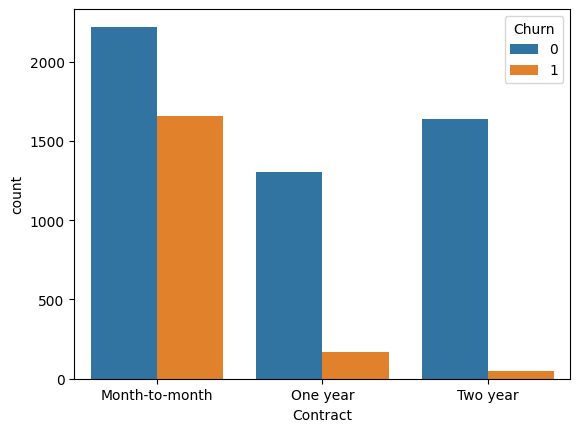

In [75]:
sns.countplot(x='Contract', hue='Churn', data=df)




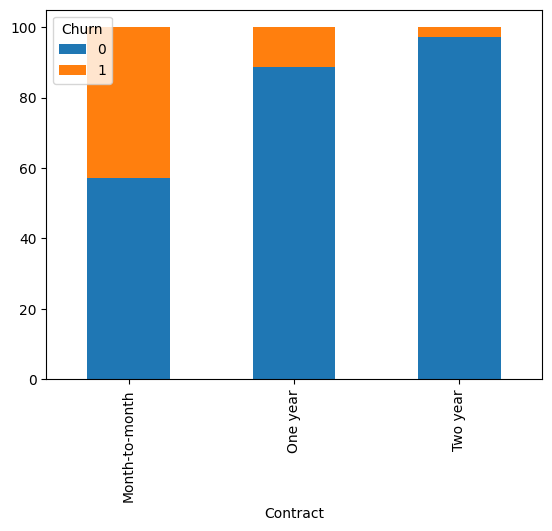

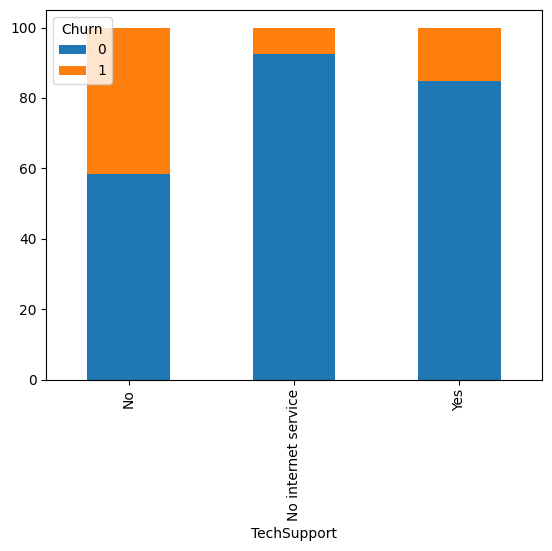

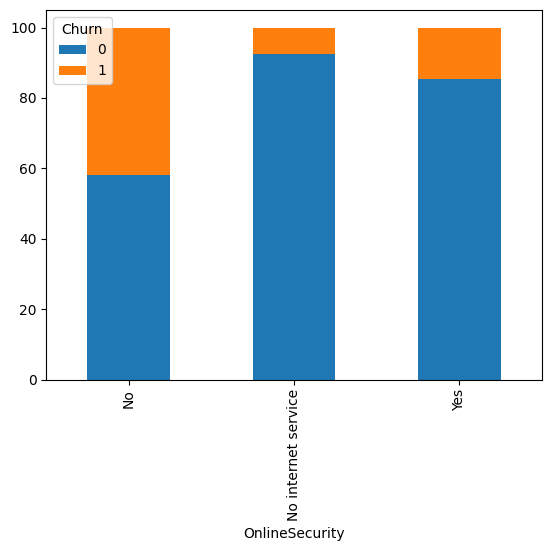

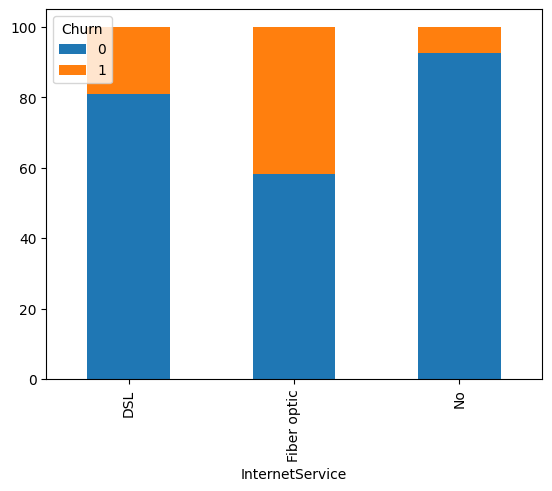

In [76]:
for z in top_cat_features:
    contract_churn = pd.crosstab(

        df[z],

        df['Churn'],

        normalize='index'

    ) * 100

    contract_churn.plot(kind='bar', stacked=True)

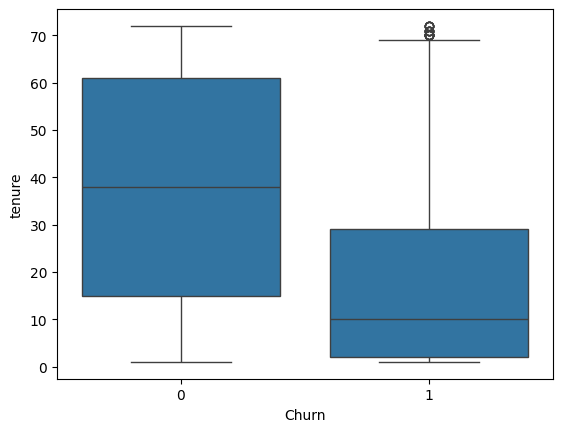

In [77]:
for z in top_num_features:
    sns.boxplot(x='Churn',y=z,data=df)

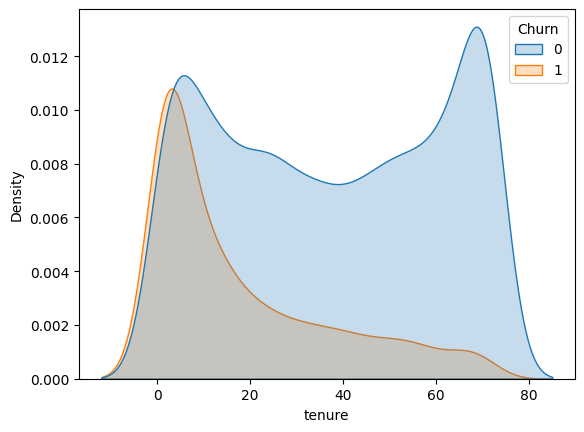

In [78]:
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True)

plt.show()

these plots validate the MI findings as they prove to be key indicators of churn

they also serve to inform feature engieering decisions for my baseline as i can identify from these that i should:

one hot encoding the categorical features

scale the numeric features

use yeo-johnson transformation to handle skew dynamically 




for my second interation i should: 

bin the tenure into groups as it shows non-linear behaviour as seen in the kde 

collapse no and no-internet etc for categorical features

create interaction features for ...

 there is clear non-linear behaviour in tenure so i should...

# first iteration

# feature eingineering

test/train split

In [79]:
df_copy = df.copy()
df_copy.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [80]:
X = df_copy.drop('Churn', axis=1)

y = df_copy['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

preprocessor

In [81]:
def build_preprocessor(df_copy):
    df_copy_num = df_copy.select_dtypes(include=['number']).columns.tolist()
    print(df_copy_num)
    df_copy_cat = df_copy.select_dtypes(include=['str']).columns.tolist()
    print(df_copy_cat)


    transformer = []

    #numeric columns
    #scale with simple scaler and transform with yeo-johnson
    if df_copy_num:
        numeric_pipeline = Pipeline([
            ('power', PowerTransformer(method='yeo-johnson')),
            ('scaler', StandardScaler())
        ])

        transformer.append(('numeric', numeric_pipeline, df_copy_num))
    
    #categorcial columns
    #use one hot encodiing 
    if df_copy_cat:
        categorical_pipeline = Pipeline([
            ('encoder', OneHotEncoder())
        ])

        transformer.append(("categorical", categorical_pipeline, df_copy_cat))

    
    return ColumnTransformer(transformer)

In [82]:
preprocessor = build_preprocessor(X_train)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processsed = preprocessor.transform(X_test)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


# model trainer

baseline model

In [83]:
model = Pipeline(steps=[

    ('preprocess', preprocessor),

    ('classifier', LogisticRegression(max_iter=1000, random_state=42))

])

In [84]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [85]:
y_pred = model.predict(X_test)

y_proba = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407

ROC-AUC: 0.8381472891893711


baseline model completed

# next steps

based on the evaluation of the model the problem is that:

even though the model can seperate chruners from non-churners well and has learned meaningful structure from the features (.83 roc-auc), it is still failing to capture churners as it only captures around half of churners (.53 recall). Furthermore, when the model predicts that someone will churn it is right around 2/3 times (.63 precision).

this means that:

the model has captured meaningful structure but has failed to accurately predict churners at the probability threshold of 0.5

thus by dynamically adusting the threshold these metrics should improve 

# second iteration

# dynamic optimal threshold

add code for using validation set for finding optimal threshold

In [86]:
X_train_main, X_val, y_train_main, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

In [87]:
y_proba = model.predict_proba(X_val)[:,1]
best_threshold = None
thresholds = np.arange(0.1, 0.91, 0.01)
best_recall = 0

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)

    if precision >= 0.6 and recall > best_recall:
        best_recall = recall
        best_threshold = t

print(best_threshold, best_recall)


0.4299999999999998 0.5652173913043478


under the business constriant of having a precision of .6 as to not waste resources the optimal recall and probability threshold has been found

the next step is to implement this decision boundary in the model itself 

In [88]:
y_proba = model.predict_proba(X_test)[:,1]

y_pred = (y_proba >= best_threshold).astype(int)

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1033
           1       0.60      0.63      0.62       374

    accuracy                           0.79      1407
   macro avg       0.73      0.74      0.74      1407
weighted avg       0.79      0.79      0.79      1407

ROC-AUC: 0.8381472891893711


by adjusting the decision boundary the recall has improved and all the evaluation metrics have seeming hit a plateu. to further improve these metrics it would be neccesary to capture the non-linear behaviour of features like 'tenure' using gradient boosting models to capture the non-linear behaviour and interaction behaviour between features.

# third iteration

In [89]:


model = Pipeline(steps=[

    ('preprocess', preprocessor),

    ('classifier', XGBClassifier(eval_metric="logloss"))

])

param_grid = {
    "classifier__n_estimators": [100, 200, 500],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [3, 5, 10],
    "classifier__subsample": [0.6, 0.8, 1.0],
    "classifier__colsample_bytree": [0.6, 0.8, 1.0]

}

gridSearch = GridSearchCV(

    model,

    param_grid,

    cv=5,

    scoring="roc_auc",

    n_jobs=-1

)

gridSearch.fit(X_train, y_train)

best_model = gridSearch.best_estimator_



In [92]:
xbg_model = best_model
y_pred = xbg_model.predict(X_test)

y_proba = xbg_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

ROC-AUC: 0.8414345320985033


In [94]:
y_proba = xbg_model.predict_proba(X_val)[:,1]
best_threshold = None
thresholds = np.arange(0.1, 0.91, 0.01)
best_recall = 0

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)

    if precision >= 0.6 and recall > best_recall:
        best_recall = recall
        best_threshold = t

print(best_threshold, best_recall)

0.3699999999999999 0.6789297658862876


In [95]:
y_proba = xbg_model.predict_proba(X_test)[:,1]

y_pred = (y_proba >= .41).astype(int)

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1033
           1       0.60      0.65      0.62       374

    accuracy                           0.79      1407
   macro avg       0.74      0.75      0.74      1407
weighted avg       0.80      0.79      0.79      1407

ROC-AUC: 0.8414345320985033


there is a clear plataeu of roc-auc and similar eval metrics, this means that the baseline and gbmodel both recover the same signal implying that the feature space is roughly linearly seperable already. the next improvement in the model will come from better feature representation not from model improvement. the model may be able to discover key interactions however because of the low count of these cases, there is the chance of high variance leading the model to overfit these patterns and thus leading to weaker generalisation overall

# Feature engineering

In [96]:
service_cols = [

    'OnlineSecurity',

    'OnlineBackup',

    'DeviceProtection',

    'TechSupport',

    'StreamingTV',

    'StreamingMovies'

]

df_copy['NumServicesUsed'] = (df_copy[service_cols] == 'Yes').sum(axis=1)

In [97]:
df_copy['NoProtectionServices'] = (

    (df_copy['OnlineSecurity'] == 'No') &

    (df_copy['DeviceProtection'] == 'No') &

    (df_copy['TechSupport'] == 'No')

).astype(int)

In [98]:
df_copy['TenureGroup'] = pd.cut(

    df['tenure'],

    bins=[0, 6, 12, 24, 48, 72],

    labels=[0, 1, 2, 3, 4]

)

In [99]:
df_copy['IsNewCustomer'] = (df_copy['tenure'] <= 6).astype(int)

In [100]:
df_copy.head()
df_copy.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   gender                7032 non-null   str     
 1   SeniorCitizen         7032 non-null   int64   
 2   Partner               7032 non-null   str     
 3   Dependents            7032 non-null   str     
 4   tenure                7032 non-null   int64   
 5   PhoneService          7032 non-null   str     
 6   MultipleLines         7032 non-null   str     
 7   InternetService       7032 non-null   str     
 8   OnlineSecurity        7032 non-null   str     
 9   OnlineBackup          7032 non-null   str     
 10  DeviceProtection      7032 non-null   str     
 11  TechSupport           7032 non-null   str     
 12  StreamingTV           7032 non-null   str     
 13  StreamingMovies       7032 non-null   str     
 14  Contract              7032 non-null   str     
 15  PaperlessBilling    

In [101]:
def build_preprocessor_final(df_copy):
    df_copy_num = df_copy.select_dtypes(include=['number']).columns.tolist()
    
    df_copy_num.remove('NoProtectionServices')
    df_copy_num.remove('NumServicesUsed')
    df_copy_num.remove('IsNewCustomer')
    print(df_copy_num)
    df_copy_cat = df_copy.select_dtypes(include=['str','category']).columns.tolist()
    df_copy_cat.append('NoProtectionServices')
    df_copy_cat.append('NumServicesUsed')
    df_copy_num.append('IsNewCustomer')
    print(df_copy_cat)


    transformer = []

    #numeric columns
    #scale with simple scaler and transform with yeo-johnson
    if df_copy_num:
        numeric_pipeline = Pipeline([
            ('power', PowerTransformer(method='yeo-johnson')),
            ('scaler', StandardScaler())
        ])

        transformer.append(('numeric', numeric_pipeline, df_copy_num))
    
    #categorcial columns
    #use one hot encodiing 
    if df_copy_cat:
        categorical_pipeline = Pipeline([
            ('encoder', OneHotEncoder())
        ])

        transformer.append(("categorical", categorical_pipeline, df_copy_cat))

    
    return ColumnTransformer(transformer)

In [102]:

X = df_copy.drop('Churn', axis=1)

y = df_copy['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [103]:
preprocessor = build_preprocessor_final(X_train)

model = Pipeline(steps=[

    ('preprocess', preprocessor),

    ('classifier', XGBClassifier(eval_metric="logloss"))

])

param_grid = {
    "classifier__n_estimators": [100, 200, 500],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [3, 5, 10],
    "classifier__subsample": [0.6, 0.8, 1.0],
    "classifier__colsample_bytree": [0.6, 0.8, 1.0]

}

gridSearch = GridSearchCV(

    model,

    param_grid,

    cv=5,

    scoring="roc_auc",

    n_jobs=-1

)

gridSearch.fit(X_train, y_train)

best_model = gridSearch.best_estimator_

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup', 'NoProtectionServices', 'NumServicesUsed']


In [104]:
y_proba = xbg_model.predict_proba(X_test)[:,1]
best_threshold = None
thresholds = np.arange(0.1, 0.91, 0.01)
best_recall = 0

for t in thresholds:

    y_pred = (y_proba >= t).astype(int)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    if precision >= 0.6 and recall > best_recall:

        best_recall = recall

        best_threshold = t

print(best_threshold, best_recall)

0.40999999999999986 0.6497326203208557


/Users/v/Documents/dataScienceProject/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [105]:
y_proba = xbg_model.predict_proba(X_test)[:,1]

y_pred = (y_proba >= best_threshold).astype(int)

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1033
           1       0.60      0.65      0.62       374

    accuracy                           0.79      1407
   macro avg       0.74      0.75      0.74      1407
weighted avg       0.80      0.79      0.79      1407

ROC-AUC: 0.8414345320985033


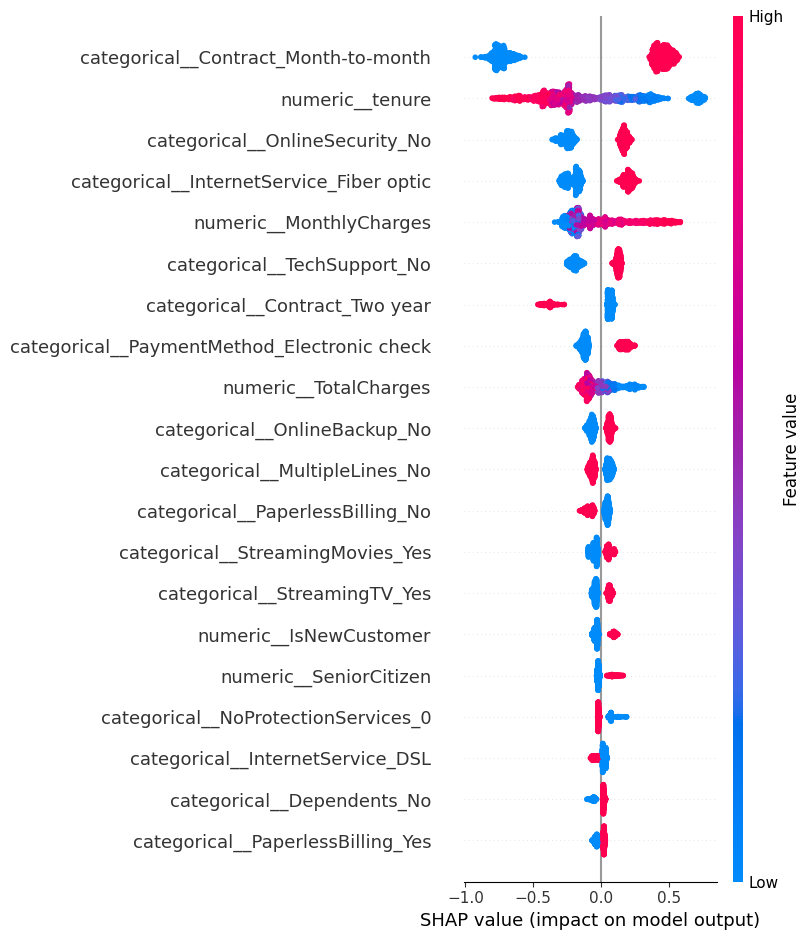

In [106]:
best_model = gridSearch.best_estimator_

preprocessor = best_model.named_steps['preprocess']

model = best_model.named_steps['classifier']

X_test_transformed = preprocessor.transform(X_test)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_transformed)

feature_names = preprocessor.get_feature_names_out()

shap.summary_plot(

    shap_values,

    X_test_transformed,

    feature_names=feature_names

)

I have now reached model convergence based on current feature representation.

Engineered behavioral features (service usage, tenure segmentation), evaluated via SHAP analysis, and found that predictive signal was dominated by contract type and tenure, indicating feature redundancy and model convergence. 

The next steps are to use the more simple model and build the components seperately in a modular and reproducible fashion.

feature engineering -- minimal -- no feature interactions or non-linear structures needed to be captured 

class weighting and stratification

model selection -- logistic regression 

model evaluation -- recall, precision and roc-auc




